# **IS4487 Module 5 - Demo code: EDA**

This notebook is designed to help you follow along with the **Module 5 Lecture and Reading**

The practice code demos are intended to give you a chance to see working code and can be a source for your lab and assignment work.  Each section contains short explanations and annotated code that reflect the steps in the reading. The content isa bit lengthy but shows you how to do a majority of the common EDA/descriptive analytics steps for any dataset - very useful for your group project.


### Topics for this demo:
- Preview data
- Check data types
- Descriptive statistics
- Check quality: missing values, duplicate records and outliers
- Visualization - Univariate and Bi/multi-variate plots
- Ethical reflection

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Demos/demo_05_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Context: Financial Risk Assesement Analytics
FinTrust Bank is a mid-sized financial institution that provides consumer loans, credit cards, and mortgages. The risk analytics team is investigating patterns in customer borrowing behavior to better understand which customers are most likely to default on their loans.

Your task is to explore the data to understand how each variable behaves in the financial risk assesment.

## Step 1: Install and Import all Necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Step 2: Load Dataset

In [ ]:
url = 'https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/fintrust_loan_data.csv'  # Replace with uploaded URL or path if needed
df = pd.read_csv(url)

## Step 3: Preview and Basic Info

In [ ]:
#Set the maximum column width to a specific value (e.g., 100 characters)
pd.set_option('display.max_colwidth', 100)

#Set the overall display width
pd.set_option('display.width', 180) # Adjust this value as needed

In [ ]:
df.shape

(200, 12)

In [ ]:
print(df.head())

  Loan_ID  Gender  Age Married     Education EmploymentStatus  ApplicantIncome  LoanAmount  LoanTerm  CreditScore  HasPreviousDefaults LoanStatus
0  LN1000    Male   52     Yes      Graduate         Employed             4417     66511.0     360.0        723.0                    0  Defaulted
1  LN1001  Female   59      No  Not Graduate         Employed             3997    238234.0     120.0        612.0                    0       Paid
2  LN1002    Male   52     Yes      Graduate         Employed             7093     87924.0     360.0        742.0                    0       Paid
3  LN1003    Male   24      No  Not Graduate         Employed             3035    109184.0      60.0        663.0                    1       Paid
4  LN1004    Male   50      No  Not Graduate         Employed             2129    215788.0       NaN        795.0                    0       Paid


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Loan_ID              200 non-null    object 
 1   Gender               200 non-null    object 
 2   Age                  200 non-null    int64  
 3   Married              200 non-null    object 
 4   Education            200 non-null    object 
 5   EmploymentStatus     200 non-null    object 
 6   ApplicantIncome      200 non-null    int64  
 7   LoanAmount           190 non-null    float64
 8   LoanTerm             190 non-null    float64
 9   CreditScore          190 non-null    float64
 10  HasPreviousDefaults  200 non-null    int64  
 11  LoanStatus           200 non-null    object 
dtypes: float64(3), int64(3), object(6)
memory usage: 18.9+ KB


###THINK:

What is a relevant target for this data? `LoanStatus` seems useful to predict, and its what the business cares about most.
Let us see what values it contains - it has been read in a string/object

In [ ]:
df['LoanStatus'].value_counts(normalize = True)

,proportion
LoanStatus,
Paid,0.75
Defaulted,0.25


## Step 4: Change data types as needed

Check data types. Check whether any object (string/text) data types should actually be categorical? Having the correct datatype matters - when a column is a string (Object) we cant do much with it, so we will want to convert those to categorical.


In [ ]:
# change the target to categorical
df['LoanStatus'] = df['LoanStatus'].astype('category')
#change other objects that should also be categorical
df['Gender'] = df['Gender'].astype('category')
df['Married'] = df['Married'].astype('category')
df['EmploymentStatus'] = df['EmploymentStatus'].astype('category')
df['Education'] = df['Education'].astype('category')

## Step 5: Descriptive Statistics



### 5a. Univariate
look to see whether mins and max make sense, whether var is too high compared to the mean.

There is a negative loan amount as the minimum - error? possibly outlier?



In [ ]:
df.describe()

,Age,ApplicantIncome,LoanAmount,LoanTerm,CreditScore,HasPreviousDefaults
count,200.000000,200.000000,190.000000,190.000000,190.000000,200.000000
mean,43.545000,4905.160000,146434.378947,170.463158,656.410526,0.140000
std,12.649825,1518.019844,52186.479879,114.499307,71.299427,0.347858
min,21.000000,888.000000,-24040.000000,36.000000,447.000000,0.000000
25%,32.750000,3973.000000,108421.500000,60.000000,611.250000,0.000000
50%,45.500000,4865.000000,151791.000000,180.000000,658.000000,0.000000
75%,53.000000,5797.750000,184586.250000,240.000000,702.500000,0.000000
max,64.000000,9175.000000,267868.000000,360.000000,820.000000,1.000000


In [ ]:
# use print() when you want to view the output of multiple commands in the same cell

print ("Descriptive stats for loan amount")
print("mean = ", df['LoanAmount'].mean())
print("median = ", df['LoanAmount'].median())

print("skew = ", df['LoanAmount'].skew())   #is the tail lop-sided? we see longer tail on the left than a normal distribution
print("kurtosis = ", df['LoanAmount'].kurt())   #is the tail thin or fat? we see thinner tail than a normal distribution


Descriptive stats for loan amount
mean =  146434.37894736842
median =  151791.0
skew =  -0.20521691929955127
kurtosis =  -0.19699988261284807


### 5b. Bivariate and Multivariate

In [ ]:
# correlation of two numeric variables
correlation = df[['LoanAmount', 'CreditScore']].corr()
print(correlation)

             LoanAmount  CreditScore
LoanAmount     1.000000    -0.035202
CreditScore   -0.035202     1.000000


In [ ]:
# correlation of all numeric variables
df.corr(numeric_only = True)

,Age,ApplicantIncome,LoanAmount,LoanTerm,CreditScore,HasPreviousDefaults
Age,1.000000,0.027884,0.003517,-0.051259,0.034565,-0.027705
ApplicantIncome,0.027884,1.000000,-0.100681,-0.048748,0.019006,0.083016
LoanAmount,0.003517,-0.100681,1.000000,-0.007191,-0.035202,0.025250
LoanTerm,-0.051259,-0.048748,-0.007191,1.000000,-0.089444,-0.068970
CreditScore,0.034565,0.019006,-0.035202,-0.089444,1.000000,-0.001502
HasPreviousDefaults,-0.027705,0.083016,0.025250,-0.068970,-0.001502,1.000000


In [ ]:
# cross tabulation between two categorical variables with % in each
pd.crosstab( df['Married'], df['LoanStatus'],  normalize = True)


LoanStatus,Defaulted,Paid
Married,,
No,0.13,0.435
Yes,0.12,0.315


In [ ]:
# for each loan status outcome, did mean or women differ in the avg loan amount
df.groupby(['LoanStatus', 'Gender'], observed = True)['LoanAmount'].mean()

LoanStatus  Gender
Defaulted   Female    140915.869565
            Male      157977.250000
Paid        Female    147882.685714
            Male      142989.383562
Name: LoanAmount, dtype: float64

## Step 6: Check for quality issues



### 6a. Check for Missing Values
we will learn to deal with these next week. For now, we will leave it be.

In [ ]:
print("\nMissing Values in each column:")
print(df.isnull().sum())


Missing Values in each column:
Loan_ID                 0
Gender                  0
Age                     0
Married                 0
Education               0
EmploymentStatus        0
ApplicantIncome         0
LoanAmount             10
LoanTerm               10
CreditScore            10
HasPreviousDefaults     0
LoanStatus              0
dtype: int64


### 6b. Check for  Duplicate Records

In [ ]:
# exact duplicates
print(df.duplicated().sum())

# partial duplicates - check if a subset of cols is duplicated - which would be an error
print(df.duplicated(subset=["Loan_ID"]).sum())

0
0


Quick TIP: when printing multiple outputs from the same cell, use `print()` to make sure both are visible, otherwise only last one is shown


### 6c. Outlier Detection


#### using IQR

In [ ]:

Q1 = df['LoanAmount'].quantile(0.25)
Q3 = df['LoanAmount'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['LoanAmount'] < Q1 - 1.5 * IQR) | (df['LoanAmount'] > Q3 + 1.5 * IQR)]
print(f"\nNumber of Loan Amount Outliers using IQR: {len(outliers)}")


Number of Loan Amount Outliers using IQR: 1


#### using z-score (std. deviations from the mean)

In [ ]:
loanamount_mean = df['LoanAmount']
loanamount_std = df['LoanAmount']
lower_bound = loanamount_mean - 3 * loanamount_std
upper_bound = loanamount_mean + 3 * loanamount_std
outliers = df[(df['LoanAmount'] < lower_bound) | (df['LoanAmount'] > upper_bound)]
print(f"\nNumber of Loan Amount Outliers using z-score: {len(outliers)}")
print(outliers)


Number of Loan Amount Outliers using z-score: 1
    Loan_ID  Gender  Age Married     Education EmploymentStatus  ApplicantIncome  LoanAmount  LoanTerm  CreditScore  HasPreviousDefaults LoanStatus
164  LN1164  Female   50      No  Not Graduate    Self-Employed             8854    -24040.0      60.0        657.0                    0       Paid


We care most about outliers in the target variable. Since the target is a categorical with only two values, there wont be outlier, which tend to be in numeric variables.

## Step 7: Visualization



### 7a. Univariate plots
Plots can be created either using `df['col'].plot(kind="plottype")`
OR
`sns.plottype()`

Below after plotting, we can use Matplotlib pyplot sub-library imported as `plt` to set titles.

Seaborn library draws pretty pictures, has several optional parameters that you can set to make the chart better.

Try them. If you ask AI, it will choose the best options for you.

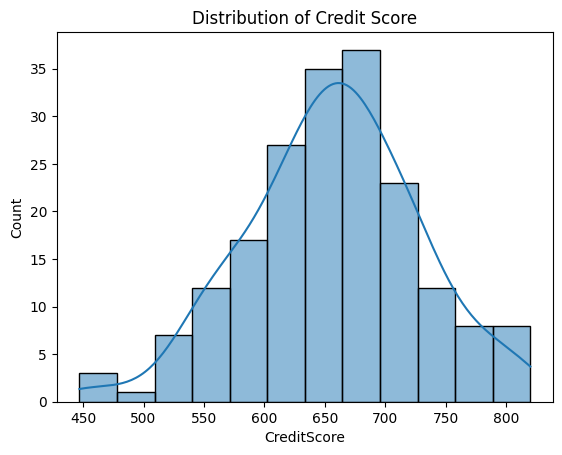

In [ ]:
# kde draws a kernel density estimate curve on top of the bars -
# an approximation of a distribution curve as if we had infinitely more x-axis values.
sns.histplot(df['CreditScore'].dropna(), kde=True)
plt.title("Distribution of Credit Score")
plt.show()


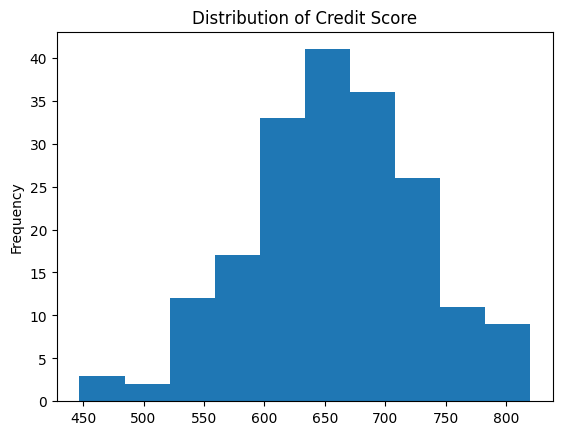

In [ ]:
df['CreditScore'].plot(kind='hist', title='Distribution of Credit Score')
plt.show()

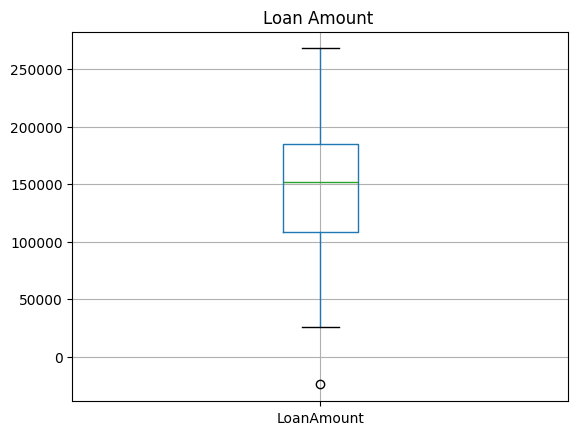

In [ ]:
df.boxplot(column='LoanAmount')
plt.title("Loan Amount ")
plt.show()

### 7b. Bivariate/multivariate plots

Typically, we want to understand the relationship between the target and other variables. So we can groupby target and summarize other variables.

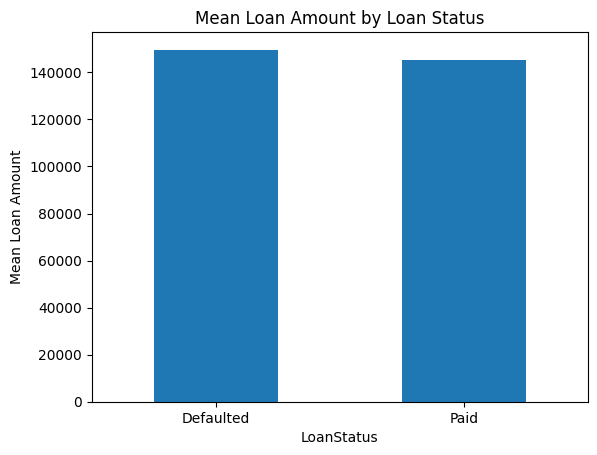

In [ ]:
# plot mean loan amount by loan status to see if higher loan amounts are more likely to default
df.groupby('LoanStatus', observed=True)['LoanAmount'].mean().plot(kind='bar')
plt.title("Mean Loan Amount by Loan Status")
plt.ylabel("Mean Loan Amount")
plt.xticks(rotation=0)
plt.show()

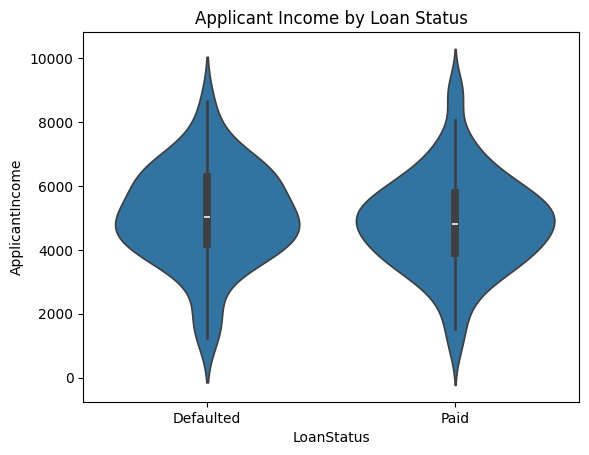

In [ ]:
# violin plots show the distribution (normal or not) and IQR/outliers in the same chart
sns.violinplot(x='LoanStatus', y='ApplicantIncome', data=df)
plt.title("Applicant Income by Loan Status")
plt.show()

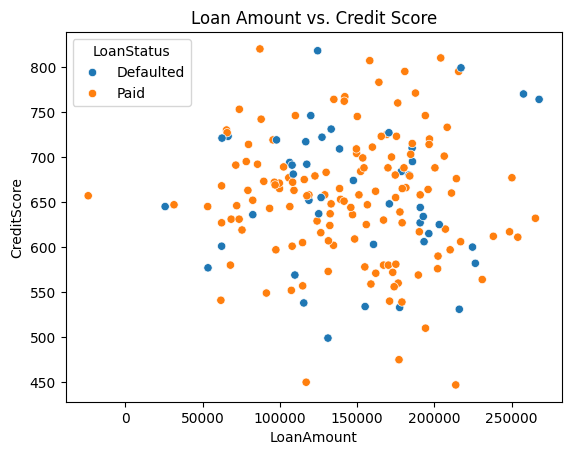

In [ ]:
# relationship between x and y grouped by a 3rd variable
sns.scatterplot( data=df, x='LoanAmount', y='CreditScore', hue='LoanStatus')
plt.title("Loan Amount vs. Credit Score")
plt.show()

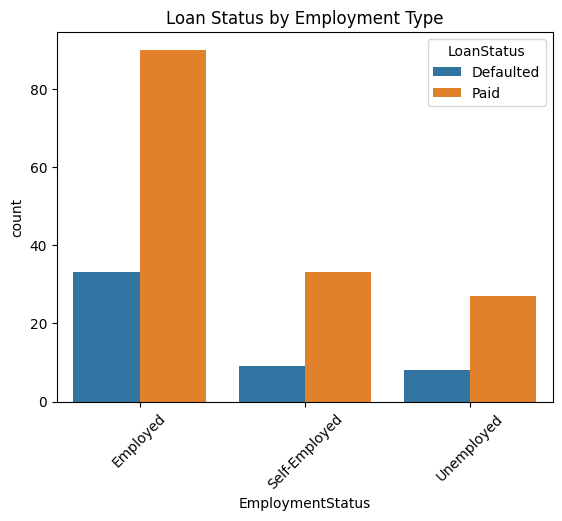

In [ ]:
# countplot is good to obtain a plot of counts one var
# against values/categories of another
sns.countplot(x='EmploymentStatus', hue='LoanStatus', data=df)
plt.title("Loan Status by Employment Type")
plt.xticks(rotation=45)
plt.show()

## Step 8: Ethical Reflection Prompt

THINK (use ChatGPT/CoPilot to help answer/understand):

What are the risks of using demographic data like 'Gender' or 'Marital Status' to assess default risk?

What other biases might exist in this dataset?

How can we mitigate bias in modeling?"

